<a href="https://colab.research.google.com/github/nkhrb/Discharge-prediction-of-mahanadi-river-basin-using-machine-learning-models/blob/main/charts_and_visualisations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

✅  Imports OK
✅  Data loaded for: ['Sundergarh', 'Kesinga', 'Bamnidhi']
✅  Style configured
Saved → optimal_perf_sundergarh.png


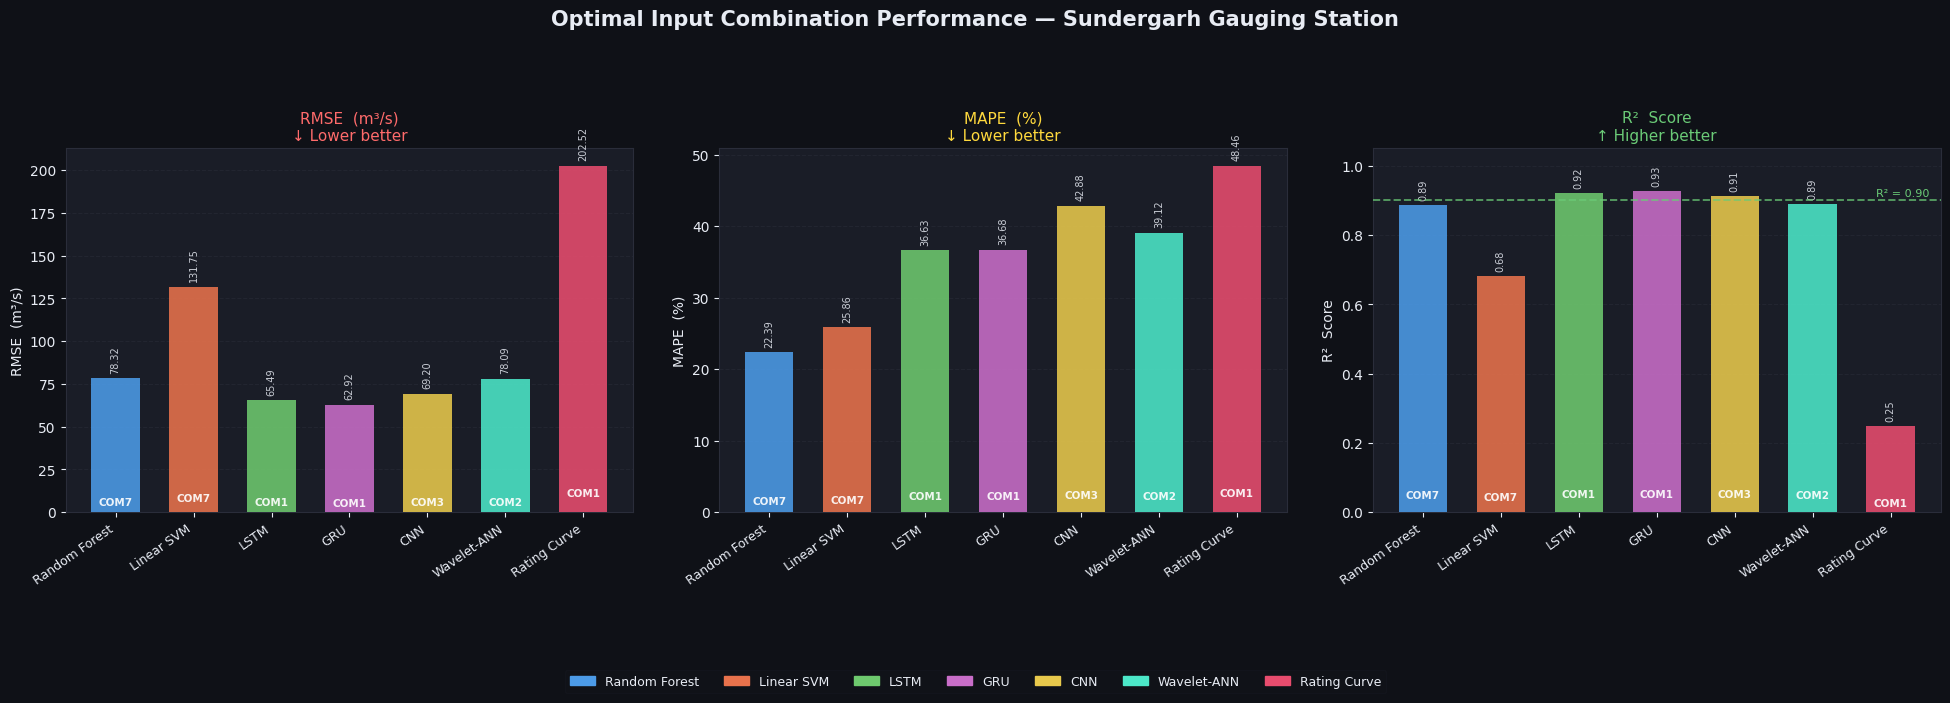

Saved → optimal_perf_kesinga.png


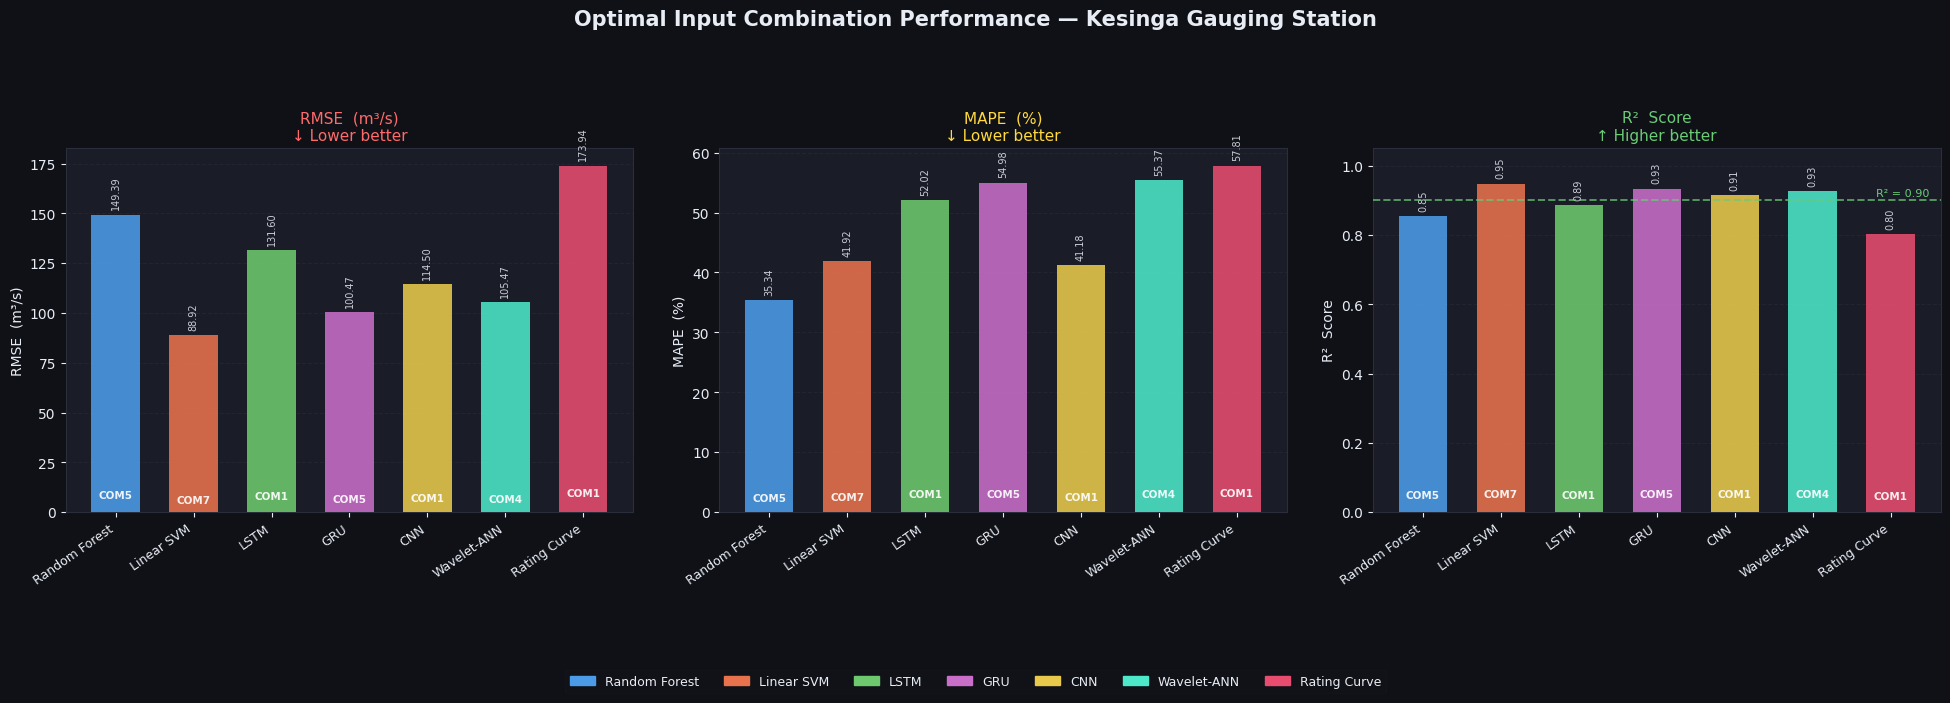

Saved → optimal_perf_bamnidhi.png


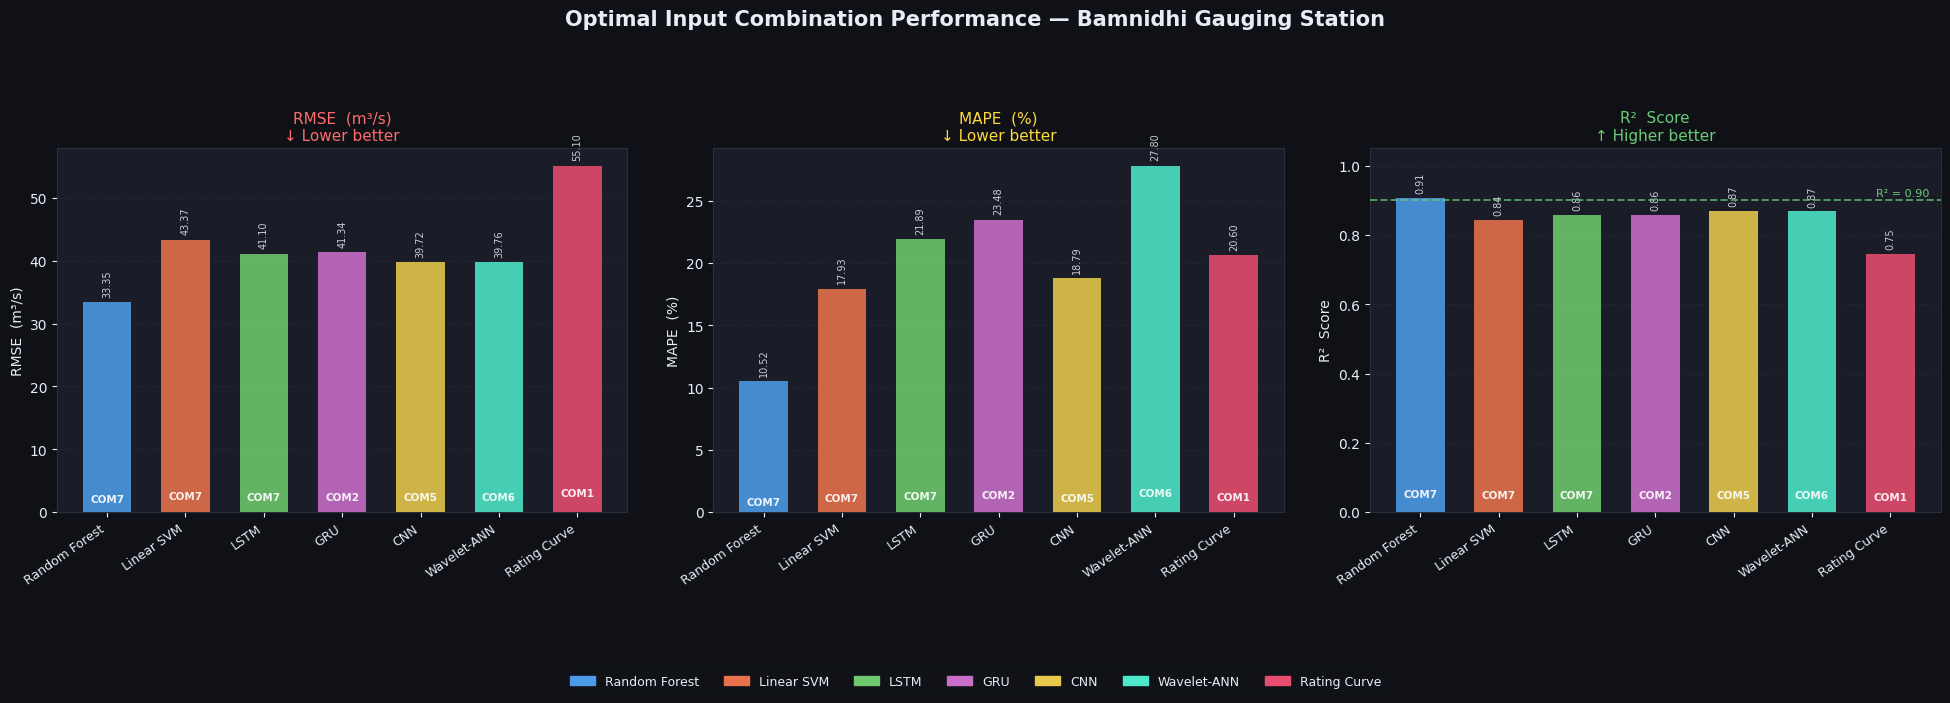

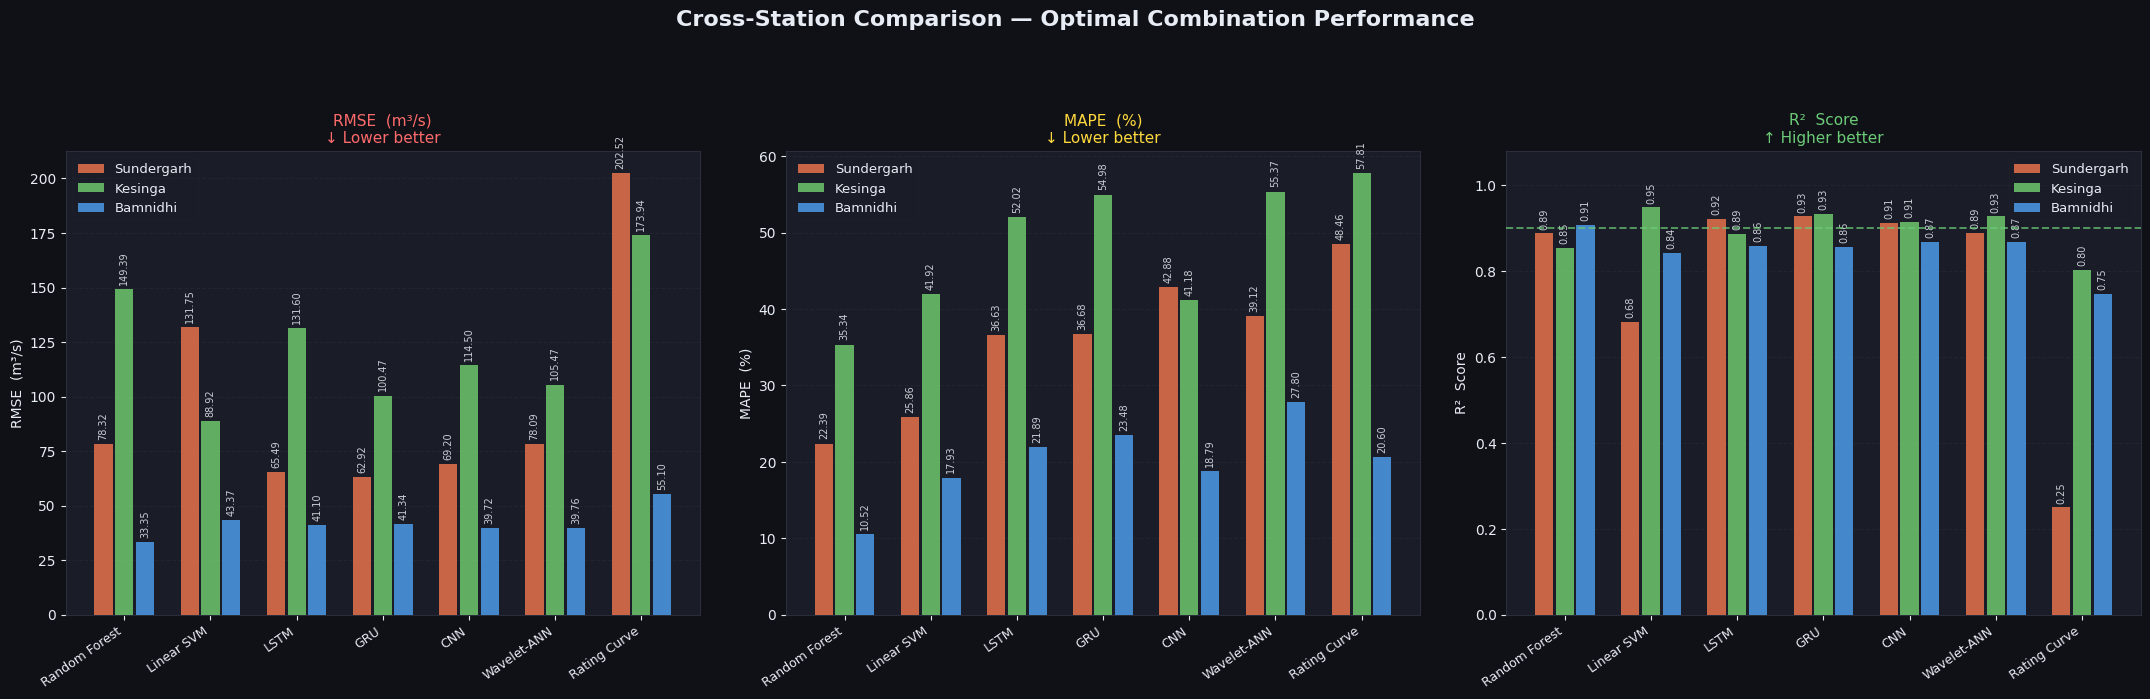

Saved → optimal_perf_cross_station.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅  All files downloaded.


In [ ]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  Optimal Combination Performance — Grouped Bar Charts               ║
# ║  Google Colab — run cell by cell                                    ║
# ╚══════════════════════════════════════════════════════════════════════╝

# ──────────────────────────────────────────────────────────────────────
# CELL 1 — Install / import dependencies
# ──────────────────────────────────────────────────────────────────────
# %matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

print("✅  Imports OK")


# ──────────────────────────────────────────────────────────────────────
# CELL 2 — Data  (from All stations_Optimal_Combinations.xlsx)
# ──────────────────────────────────────────────────────────────────────
models = [
    "Random Forest",
    "Linear SVM",
    "LSTM",
    "GRU",
    "CNN",
    "Wavelet-ANN",
    "Rating Curve",
]

# Best-combination metrics per station
# Source: "ALL STATION - Best Combinations" sheet
stations_data = {
    "Sundergarh": {
        "combo": ["COM7", "COM7", "COM1", "COM1", "COM3", "COM2", "COM1"],
        "RMSE":  [78.3187, 131.7481, 65.4918, 62.9236, 69.1997, 78.0918, 202.5242],
        "MAPE":  [22.3873, 25.8628, 36.6265, 36.6847, 42.8811, 39.1157, 48.4586],
        "R2":    [0.8878, 0.6826, 0.9216, 0.9276, 0.9124, 0.8885, 0.2499],
    },
    "Kesinga": {
        "combo": ["COM5", "COM7", "COM1", "COM5", "COM1", "COM4", "COM1"],
        "RMSE":  [149.3931, 88.9160, 131.5982, 100.4709, 114.4957, 105.4714, 173.9380],
        "MAPE":  [35.3413, 41.9169, 52.0235, 54.9763, 41.1810, 55.3698, 57.8058],
        "R2":    [0.8546, 0.9485, 0.8872, 0.9342, 0.9146, 0.9275, 0.8029],
    },
    "Bamnidhi": {
        "combo": ["COM7", "COM7", "COM7", "COM2", "COM5", "COM6", "COM1"],
        "RMSE":  [33.3494, 43.3653, 41.0970, 41.3391, 39.7230, 39.7579, 55.1002],
        "MAPE":  [10.5185, 17.9336, 21.8949, 23.4829, 18.7892, 27.8044, 20.6017],
        "R2":    [0.9071, 0.8429, 0.8589, 0.8573, 0.8682, 0.8680, 0.7464],
    },
}

print("✅  Data loaded for:", list(stations_data.keys()))


# ──────────────────────────────────────────────────────────────────────
# CELL 3 — Shared style settings
# ──────────────────────────────────────────────────────────────────────
# Model colour palette (consistent across all charts)
MODEL_COLORS = {
    "Random Forest": "#4C9BE8",
    "Linear SVM":    "#E8724C",
    "LSTM":          "#6EC96E",
    "GRU":           "#C96EC9",
    "CNN":           "#E8C94C",
    "Wavelet-ANN":   "#4CE8C9",
    "Rating Curve":  "#E84C6E",
}

BG        = "#0F1117"
PANEL_BG  = "#1A1D27"
TEXT      = "#E8ECF4"
GRID_CLR  = "#2A2D3A"
ACCENT_R2 = "#6BCB77"

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor":   PANEL_BG,
    "axes.edgecolor":   GRID_CLR,
    "axes.labelcolor":  TEXT,
    "xtick.color":      TEXT,
    "ytick.color":      TEXT,
    "text.color":       TEXT,
    "grid.color":       GRID_CLR,
    "grid.linestyle":   "--",
    "grid.alpha":       0.5,
    "font.family":      "DejaVu Sans",
    "axes.titlesize":   13,
})

legend_handles = [
    mpatches.Patch(color=MODEL_COLORS[m], label=m) for m in models
]

def add_value_labels(ax, bars, fmt="{:.2f}", offset_frac=0.015, max_val=None):
    """Add small rotated value labels on top of each bar."""
    if max_val is None:
        max_val = max(b.get_height() for b in bars)
    for bar in bars:
        h = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            h + max_val * offset_frac,
            fmt.format(h),
            ha="center", va="bottom",
            fontsize=7, color=TEXT, alpha=0.85,
            rotation=90,
        )

print("✅  Style configured")


# ──────────────────────────────────────────────────────────────────────
# CELL 4 — Figure per station: 3-panel grouped bar (RMSE | MAPE | R²)
# ──────────────────────────────────────────────────────────────────────
def plot_station(station_name, station_dict, save=True):
    """
    Creates a 1×3 grouped-bar figure for one gauging station.
    Left  panel : RMSE   (lower is better  ↓)
    Middle panel: MAPE   (lower is better  ↓)
    Right panel : R²     (higher is better ↑)
    """
    combos = station_dict["combo"]
    x      = np.arange(len(models))
    w      = 0.62                       # bar width (single bar per position)

    metrics = [
        ("RMSE", "RMSE  (m³/s)", False, "#FF6B6B"),
        ("MAPE", "MAPE  (%)",    False, "#FFD93D"),
        ("R2",   "R²  Score",   True,  ACCENT_R2),
    ]

    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    fig.patch.set_facecolor(BG)
    fig.suptitle(
        f"Optimal Input Combination Performance — {station_name} Gauging Station",
        fontsize=15, fontweight="bold", color=TEXT, y=1.02,
    )

    for ax, (key, ylabel, higher_better, accent) in zip(axes, metrics):
        vals   = station_dict[key]
        colors = [MODEL_COLORS[m] for m in models]

        bars = ax.bar(x, vals, width=w, color=colors,
                      edgecolor="none", alpha=0.88, zorder=3)

        # combo label inside bar (bottom-anchored)
        for bar, combo in zip(bars, combos):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() * 0.04,
                combo,
                ha="center", va="bottom",
                fontsize=7.5, color="white", alpha=0.9, fontweight="bold",
            )

        add_value_labels(ax, bars, max_val=max(vals))

        # R² — add a reference line at 0.90
        if key == "R2":
            ax.axhline(0.90, color=ACCENT_R2, linewidth=1.4,
                       linestyle="--", alpha=0.7, zorder=4)
            ax.text(len(models) - 0.5, 0.905, "R² = 0.90",
                    color=ACCENT_R2, fontsize=8, va="bottom", ha="right")
            ax.set_ylim(0, 1.05)

        direction = "↑ Higher better" if higher_better else "↓ Lower better"
        ax.set_title(f"{ylabel}\n{direction}",
                     fontsize=11, color=accent, pad=6)
        ax.set_xticks(x)
        ax.set_xticklabels(models, rotation=35, ha="right", fontsize=9)
        ax.set_ylabel(ylabel, fontsize=10)
        ax.yaxis.grid(True, zorder=0)
        ax.set_axisbelow(True)

    # Shared legend below all panels
    fig.legend(
        handles=legend_handles,
        loc="lower center", ncol=7,
        fontsize=9, framealpha=0.12, edgecolor=GRID_CLR,
        bbox_to_anchor=(0.5, -0.13),
    )

    plt.tight_layout(pad=2.5)

    if save:
        fname = f"optimal_perf_{station_name.lower()}.png"
        plt.savefig(fname, dpi=180, bbox_inches="tight", facecolor=BG)
        print(f"Saved → {fname}")

    plt.show()


# Plot all three stations
for station, sdata in stations_data.items():
    plot_station(station, sdata)


# ──────────────────────────────────────────────────────────────────────
# CELL 5 — Cross-station comparison: metric side-by-side for all models
# ──────────────────────────────────────────────────────────────────────
station_list   = list(stations_data.keys())
station_colors = {"Sundergarh": "#E8724C", "Kesinga": "#6EC96E", "Bamnidhi": "#4C9BE8"}

cross_metrics = [
    ("RMSE", "RMSE  (m³/s)", False, "#FF6B6B"),
    ("MAPE", "MAPE  (%)",    False, "#FFD93D"),
    ("R2",   "R²  Score",   True,  ACCENT_R2),
]

x      = np.arange(len(models))
n_st   = len(station_list)
w      = 0.24
offset = np.array([-w, 0, w])

fig_c, axes_c = plt.subplots(1, 3, figsize=(22, 7))
fig_c.patch.set_facecolor(BG)
fig_c.suptitle(
    "Cross-Station Comparison — Optimal Combination Performance",
    fontsize=16, fontweight="bold", color=TEXT, y=1.02,
)

for ax, (key, ylabel, higher_better, accent) in zip(axes_c, cross_metrics):
    for i, station in enumerate(station_list):
        vals  = stations_data[station][key]
        color = station_colors[station]
        bars  = ax.bar(x + offset[i], vals, width=w * 0.88,
                       label=station, color=color, alpha=0.85,
                       edgecolor="none", zorder=3)
        max_v = max(max(stations_data[s][key]) for s in station_list)
        add_value_labels(ax, bars, max_val=max_v, offset_frac=0.01)

    if key == "R2":
        ax.axhline(0.90, color=ACCENT_R2, linewidth=1.4,
                   linestyle="--", alpha=0.7, zorder=4)
        ax.set_ylim(0, 1.08)

    direction = "↑ Higher better" if higher_better else "↓ Lower better"
    ax.set_title(f"{ylabel}\n{direction}", fontsize=11, color=accent, pad=6)
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=35, ha="right", fontsize=9)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.yaxis.grid(True, zorder=0)
    ax.set_axisbelow(True)
    ax.legend(fontsize=9.5, framealpha=0.15, edgecolor=GRID_CLR)

plt.tight_layout(pad=2.5)
plt.savefig("optimal_perf_cross_station.png", dpi=180,
            bbox_inches="tight", facecolor=BG)
plt.show()
print("Saved → optimal_perf_cross_station.png")


# ──────────────────────────────────────────────────────────────────────
# CELL 6 (optional) — Download all PNGs from Colab
# ──────────────────────────────────────────────────────────────────────
try:
    from google.colab import files
    fnames = [
        "optimal_perf_sundergarh.png",
        "optimal_perf_kesinga.png",
        "optimal_perf_bamnidhi.png",
        "optimal_perf_cross_station.png",
    ]
    for fname in fnames:
        files.download(fname)
    print("✅  All files downloaded.")
except ImportError:
    print("ℹ️  Not in Colab — files saved in the current directory.")


✅  Imports OK
✅  Data loaded:
   Kesinga: 31 days, 7 models
   Sundergarh: 31 days, 7 models
   Bamnidhi: 31 days, 7 models
✅  Style configured
Plotting all stations — all models...
  Saved → obs_pred_kesinga_allmodels.png


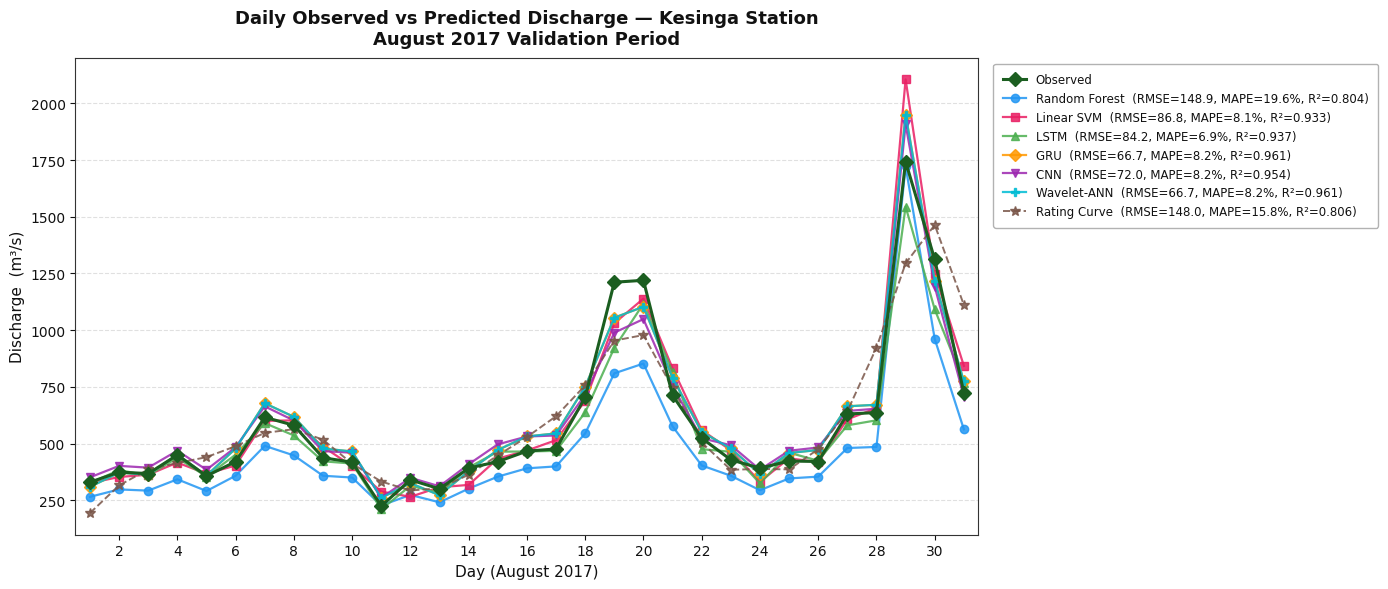

  Saved → obs_pred_sundergarh_allmodels.png


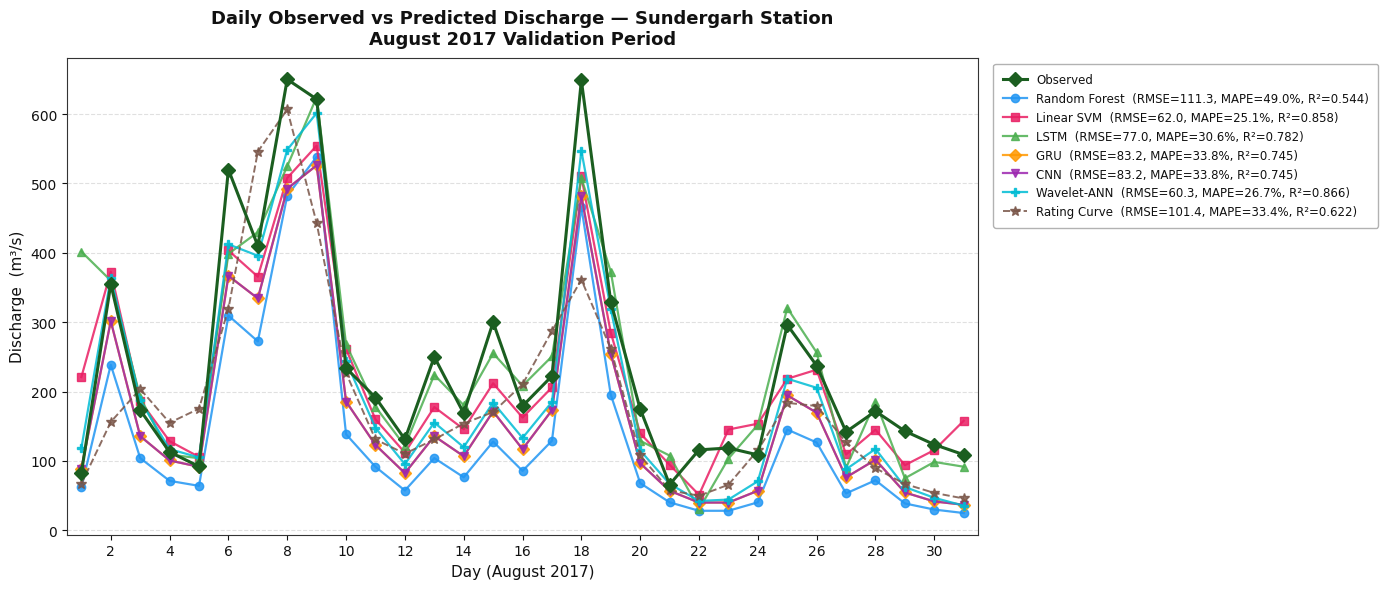

  Saved → obs_pred_bamnidhi_allmodels.png


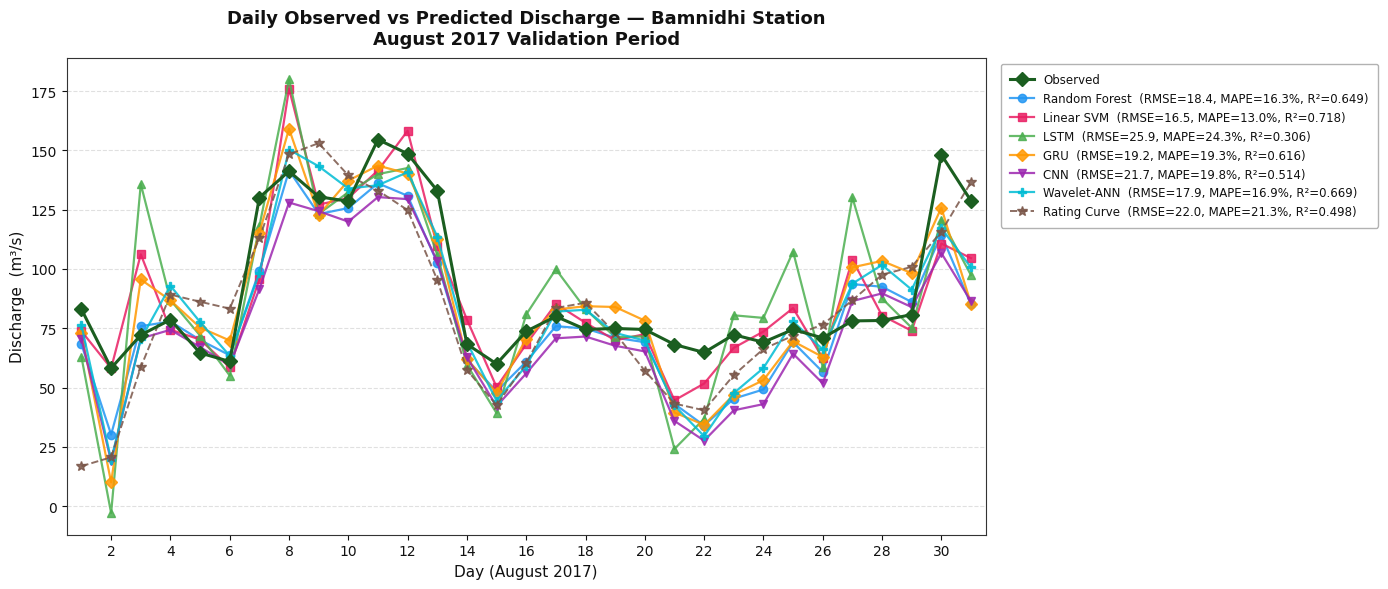


Plotting individual-model panel charts...
  Saved → obs_pred_kesinga_panels.png


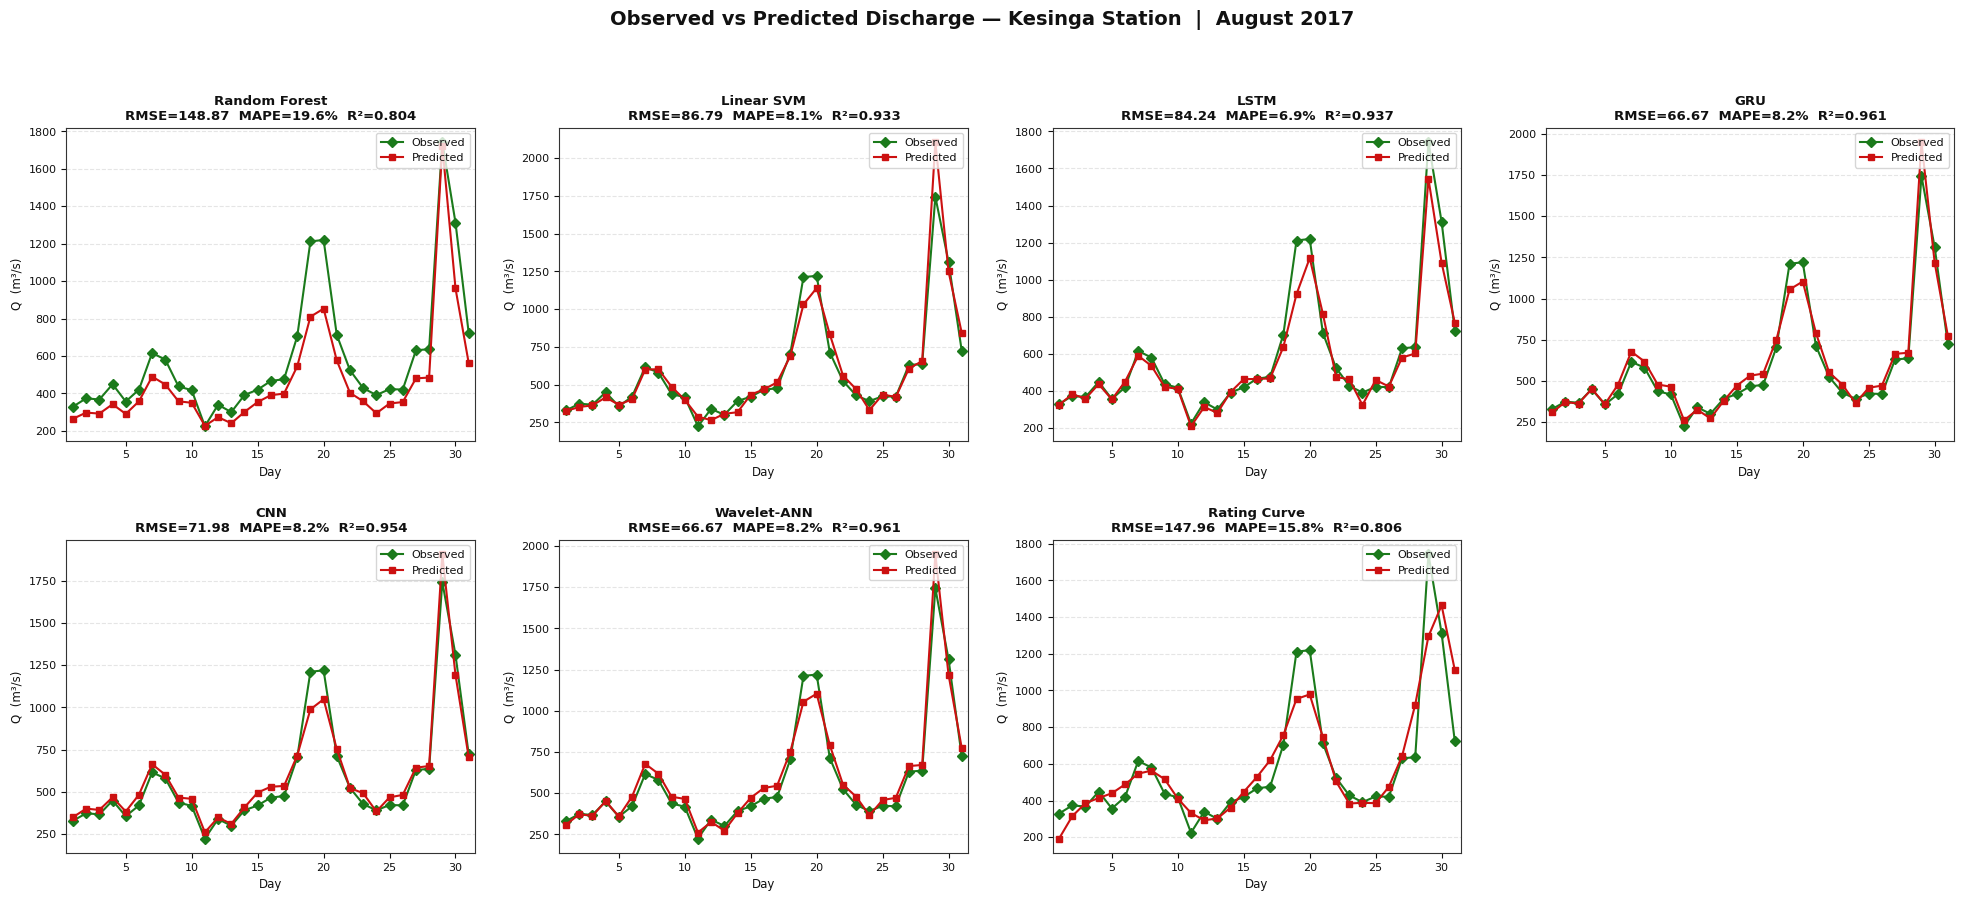

  Saved → obs_pred_sundergarh_panels.png


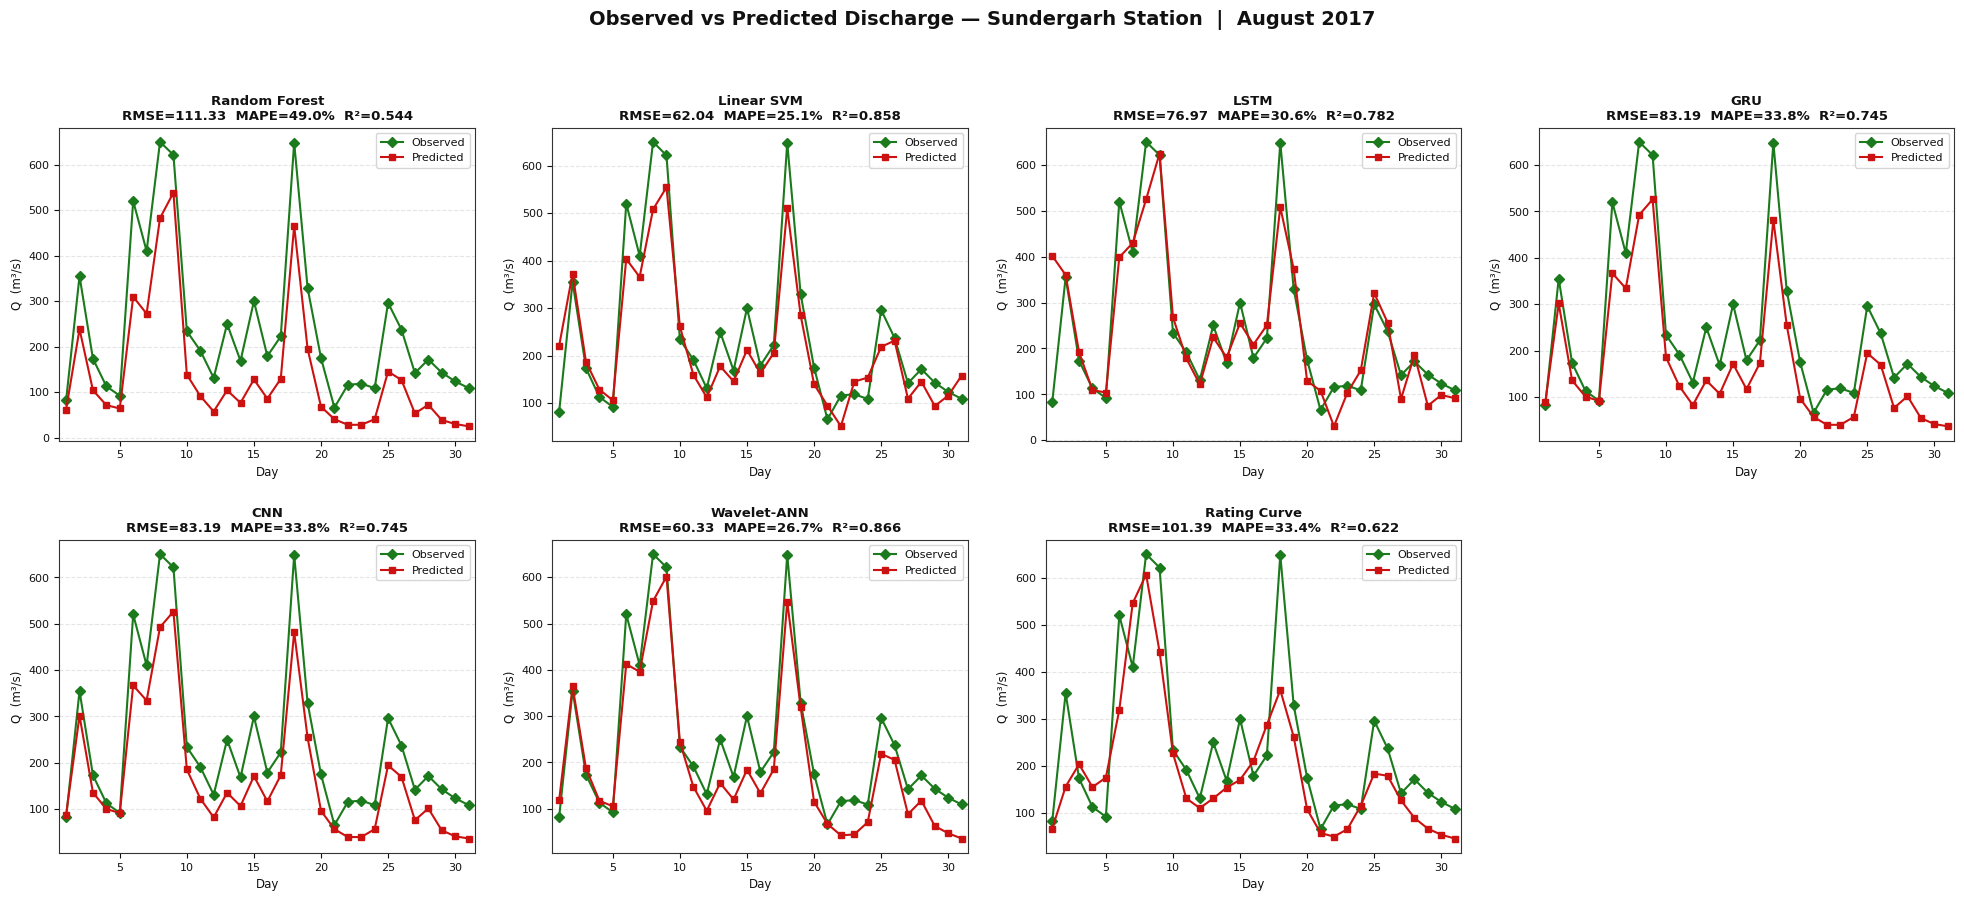

  Saved → obs_pred_bamnidhi_panels.png


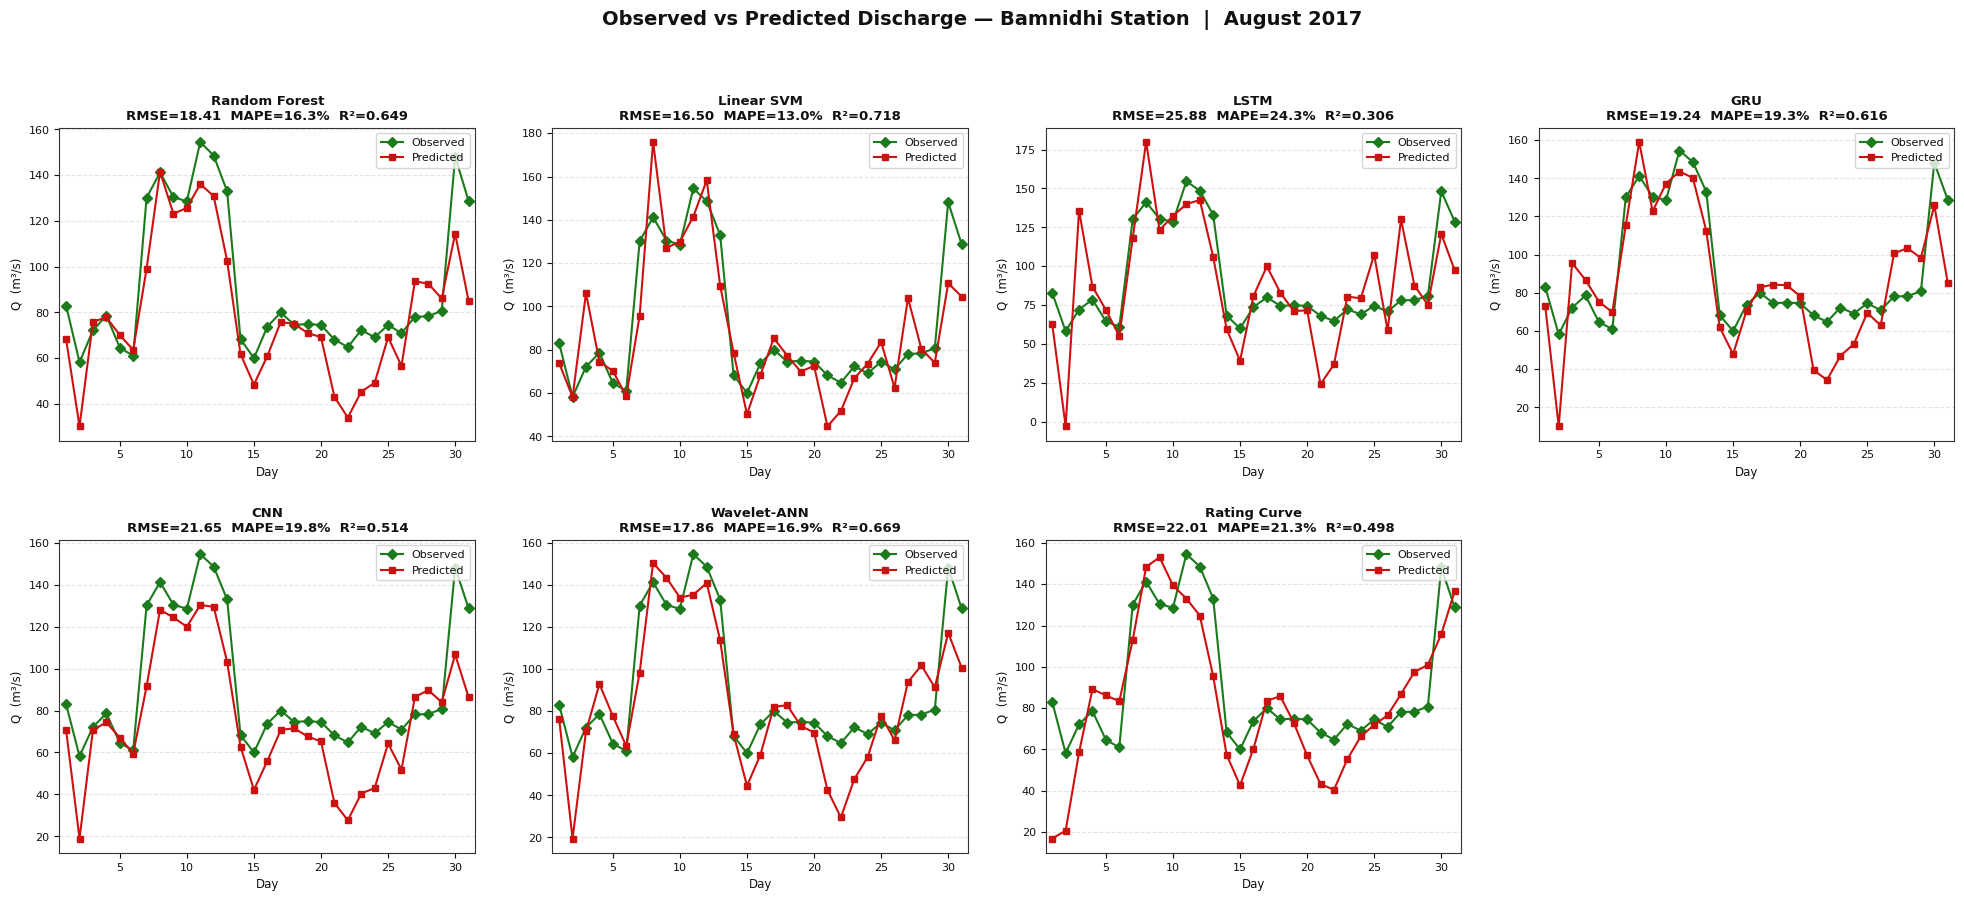

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅  All files downloaded.


In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  Observed vs Predicted Discharge — August 2017 Validation               ║
# ║  Source: Aug2017_Validation_AllStations.xlsx                            ║
# ║  Google Colab — paste all cells or run cell-by-cell                     ║
# ╚══════════════════════════════════════════════════════════════════════════╝

# ─────────────────────────────────────────────────────────────────────────────
# CELL 1 — Install openpyxl (already available in Colab, just in case)
# ─────────────────────────────────────────────────────────────────────────────
# !pip install openpyxl -q

# ─────────────────────────────────────────────────────────────────────────────
# CELL 2 — Upload your file (run this in Colab)
# ─────────────────────────────────────────────────────────────────────────────
# from google.colab import files
# uploaded = files.upload()   # upload: Aug2017_Validation_AllStations.xlsx

# ─────────────────────────────────────────────────────────────────────────────
# CELL 3 — Imports
# ─────────────────────────────────────────────────────────────────────────────
# %matplotlib inline
import openpyxl
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.lines import Line2D
import warnings
warnings.filterwarnings("ignore")

print("✅  Imports OK")


# ─────────────────────────────────────────────────────────────────────────────
# CELL 4 — Load data from Excel
# ─────────────────────────────────────────────────────────────────────────────
EXCEL_FILE = "Aug2017_Validation_AllStations.xlsx"   # ← change if filename differs

wb = openpyxl.load_workbook(EXCEL_FILE, data_only=True)

# Sheet names in the workbook
STATIONS = ["Kesinga", "Sundergarh", "Bamnidhi"]

# Column layout (1-indexed):
#   B=Observed, C=RF_pred, E=SVM_pred, G=LSTM_pred,
#   I=GRU_pred, K=CNN_pred, M=WANN_pred, O=RC_pred
#   Data rows: 5 → 35  (31 days of August 2017)
#   Summary rows: 37=RMSE, 38=MAE, 39=MAPE, 40=R²

COL_OBS  = 2    # B
COL_PRED = {    # first predicted column per model (every 2 cols)
    "Random Forest": 3,   # C
    "Linear SVM":    5,   # E
    "LSTM":          7,   # G
    "GRU":           9,   # I
    "CNN":           11,  # K
    "Wavelet-ANN":   13,  # M
    "Rating Curve":  15,  # O
}
DATA_START_ROW = 5
DATA_END_ROW   = 35

# Summary stat rows
ROW_RMSE = 37
ROW_MAPE = 39
ROW_R2   = 40

# Column index for each model's summary (same pattern: every 2 cols from C)
COL_STAT = {m: c for m, c in COL_PRED.items()}

all_data = {}

for station in STATIONS:
    ws = wb[station]
    days = list(range(1, DATA_END_ROW - DATA_START_ROW + 2))  # 1..31

    observed = []
    for r in range(DATA_START_ROW, DATA_END_ROW + 1):
        v = ws.cell(row=r, column=COL_OBS).value
        observed.append(float(v) if v is not None else np.nan)

    models_ts  = {}
    models_stats = {}
    for model, col in COL_PRED.items():
        preds = []
        for r in range(DATA_START_ROW, DATA_END_ROW + 1):
            v = ws.cell(row=r, column=col).value
            preds.append(float(v) if v is not None else np.nan)
        models_ts[model] = preds

        rmse = ws.cell(row=ROW_RMSE, column=col).value
        mape = ws.cell(row=ROW_MAPE, column=col).value
        r2   = ws.cell(row=ROW_R2,   column=col).value
        models_stats[model] = {
            "RMSE": float(rmse) if rmse else np.nan,
            "MAPE": float(mape) if mape else np.nan,
            "R2":   float(r2)   if r2   else np.nan,
        }

    all_data[station] = {
        "days":     days,
        "observed": observed,
        "models":   models_ts,
        "stats":    models_stats,
    }

print("✅  Data loaded:")
for st, d in all_data.items():
    print(f"   {st}: {len(d['days'])} days, {len(d['models'])} models")


# ─────────────────────────────────────────────────────────────────────────────
# CELL 5 — Style configuration
# ─────────────────────────────────────────────────────────────────────────────
MODELS = list(COL_PRED.keys())

# Marker + colour per model  (matching the reference photo's red-square /
# green-diamond style, extended to 7 models)
MODEL_STYLE = {
    "Random Forest": dict(color="#2196F3", marker="o",  ls="-",  lw=1.6, ms=6),
    "Linear SVM":    dict(color="#E91E63", marker="s",  ls="-",  lw=1.6, ms=6),
    "LSTM":          dict(color="#4CAF50", marker="^",  ls="-",  lw=1.6, ms=6),
    "GRU":           dict(color="#FF9800", marker="D",  ls="-",  lw=1.6, ms=6),
    "CNN":           dict(color="#9C27B0", marker="v",  ls="-",  lw=1.6, ms=6),
    "Wavelet-ANN":   dict(color="#00BCD4", marker="P",  ls="-",  lw=1.6, ms=6),
    "Rating Curve":  dict(color="#795548", marker="*",  ls="--", lw=1.4, ms=7),
}
OBS_STYLE = dict(color="#1B5E20", marker="D", ls="-", lw=2.2, ms=7)

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
    "axes.edgecolor":   "#333333",
    "axes.labelcolor":  "#111111",
    "xtick.color":      "#111111",
    "ytick.color":      "#111111",
    "text.color":       "#111111",
    "grid.color":       "#CCCCCC",
    "grid.linestyle":   "--",
    "grid.alpha":       0.6,
    "font.family":      "DejaVu Sans",
    "axes.titlesize":   12,
    "axes.labelsize":   11,
})

print("✅  Style configured")


# ─────────────────────────────────────────────────────────────────────────────
# CELL 6 — Plot: All models vs Observed for each station (one figure each)
# ─────────────────────────────────────────────────────────────────────────────
def plot_station_all_models(station, data, save=True):
    """
    One figure per station: Observed + all 7 predicted lines.
    Matches the reference photo (day on x-axis, discharge on y-axis,
    line+marker per model, legend with RMSE/R² annotation).
    """
    days     = data["days"]
    observed = data["observed"]

    fig, ax = plt.subplots(figsize=(14, 6))
    fig.patch.set_facecolor("white")

    # Observed line
    ax.plot(days, observed, label="Observed",
            color=OBS_STYLE["color"], marker=OBS_STYLE["marker"],
            ls=OBS_STYLE["ls"], lw=OBS_STYLE["lw"],
            ms=OBS_STYLE["ms"], zorder=10)

    # Predicted lines
    for model in MODELS:
        st = MODEL_STYLE[model]
        preds = data["models"][model]
        stats = data["stats"][model]
        lbl = (f"{model}  "
               f"(RMSE={stats['RMSE']:.1f}, "
               f"MAPE={stats['MAPE']:.1f}%, "
               f"R²={stats['R2']:.3f})")
        ax.plot(days, preds, label=lbl,
                color=st["color"], marker=st["marker"],
                ls=st["ls"], lw=st["lw"], ms=st["ms"],
                alpha=0.85)

    ax.set_title(f"Daily Observed vs Predicted Discharge — {station} Station\n"
                 f"August 2017 Validation Period",
                 fontsize=13, fontweight="bold", pad=10)
    ax.set_xlabel("Day (August 2017)", fontsize=11)
    ax.set_ylabel("Discharge  (m³/s)", fontsize=11)
    ax.set_xticks(days)
    ax.set_xlim(0.5, len(days) + 0.5)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(2))
    ax.yaxis.grid(True, zorder=0)
    ax.set_axisbelow(True)

    # Legend outside right
    ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1),
              fontsize=8.5, framealpha=0.9,
              edgecolor="#AAAAAA", borderpad=0.8)

    plt.tight_layout()
    if save:
        fname = f"obs_pred_{station.lower()}_allmodels.png"
        plt.savefig(fname, dpi=180, bbox_inches="tight")
        print(f"  Saved → {fname}")
    plt.show()


print("Plotting all stations — all models...")
for station in STATIONS:
    plot_station_all_models(station, all_data[station])


# ─────────────────────────────────────────────────────────────────────────────
# CELL 7 — Plot: Individual model panels (3×3 grid) per station
#           Replicates the exact reference-photo style:
#           Observed (green ◆) + Predicted (red ■) on same axes
# ─────────────────────────────────────────────────────────────────────────────
def plot_station_individual(station, data, save=True):
    """
    7 sub-plots (one per model) arranged in a 2×4 grid.
    Each sub-plot: Observed (green diamond line) + Predicted (red square line).
    Matches Fig 4.22 style from the reference photo.
    """
    days     = data["days"]
    observed = data["observed"]

    ncols = 4
    nrows = 2
    fig, axes = plt.subplots(nrows, ncols, figsize=(20, 9), sharey=False)
    fig.patch.set_facecolor("white")
    fig.suptitle(
        f"Observed vs Predicted Discharge — {station} Station  |  August 2017",
        fontsize=14, fontweight="bold", y=1.01
    )

    axes_flat = axes.flatten()

    for idx, model in enumerate(MODELS):
        ax    = axes_flat[idx]
        preds = data["models"][model]
        stats = data["stats"][model]

        # Observed — green diamond line (matching reference photo)
        ax.plot(days, observed,
                color="#1B7A1B", marker="D", ls="-", lw=1.5, ms=5,
                label="Observed", zorder=5)

        # Predicted — red square line
        ax.plot(days, preds,
                color="#CC1111", marker="s", ls="-", lw=1.5, ms=5,
                label=f"Predicted", zorder=5)

        ax.set_title(
            f"{model}\n"
            f"RMSE={stats['RMSE']:.2f}  MAPE={stats['MAPE']:.1f}%  R²={stats['R2']:.3f}",
            fontsize=9.5, fontweight="bold"
        )
        ax.set_xlabel("Day", fontsize=8.5)
        ax.set_ylabel("Q  (m³/s)", fontsize=8.5)
        ax.xaxis.set_major_locator(ticker.MultipleLocator(5))
        ax.set_xlim(0.5, len(days) + 0.5)
        ax.yaxis.grid(True, alpha=0.5)
        ax.set_axisbelow(True)
        ax.tick_params(labelsize=8)
        ax.legend(fontsize=8, loc="upper right", framealpha=0.8)

    # Hide the last (empty) subplot if 7 models in 2×4 grid
    if len(MODELS) < nrows * ncols:
        for j in range(len(MODELS), nrows * ncols):
            axes_flat[j].set_visible(False)

    plt.tight_layout(pad=2.0)
    if save:
        fname = f"obs_pred_{station.lower()}_panels.png"
        plt.savefig(fname, dpi=180, bbox_inches="tight")
        print(f"  Saved → {fname}")
    plt.show()


print("\nPlotting individual-model panel charts...")
for station in STATIONS:
    plot_station_individual(station, all_data[station])


# ─────────────────────────────────────────────────────────────────────────────
# CELL 8 (optional) — Download all saved PNGs from Colab
# ─────────────────────────────────────────────────────────────────────────────
try:
    from google.colab import files
    import os
    for fname in os.listdir("."):
        if fname.endswith(".png") and fname.startswith("obs_pred_"):
            files.download(fname)
    print("✅  All files downloaded.")
except ImportError:
    print("ℹ️  Not in Colab — files saved in the current directory.")
